# Task 3

In [4]:
import torch, sys, os

print("Python:", sys.version)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
Torch: 2.6.0+cu124
CUDA available: True
GPU: Tesla T4


## Part 1

In [5]:
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()
token = user_secrets.get_secret("HF_TOKEN")
if token is None:
    print("unsuccessful")
    raise Exception()
login(token=token, add_to_git_credential=False)
print("Hugging Face login successful.")



Hugging Face login successful.


## Part 2

In [6]:
from datasets import load_dataset

raw_datasets = load_dataset("swag", "regular")
print(raw_datasets)

README.md: 0.00B [00:00, ?B/s]

regular/train-00000-of-00001.parquet:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

regular/validation-00000-of-00001.parque(…):   0%|          | 0.00/4.81M [00:00<?, ?B/s]

regular/test-00000-of-00001.parquet:   0%|          | 0.00/4.78M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/73546 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/20006 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/20005 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 73546
    })
    validation: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 20006
    })
    test: Dataset({
        features: ['video-id', 'fold-ind', 'startphrase', 'sent1', 'sent2', 'gold-source', 'ending0', 'ending1', 'ending2', 'ending3', 'label'],
        num_rows: 20005
    })
})


## Part 3

,video-id,fold-ind,startphrase,sent1,sent2,gold-source,ending0,ending1,ending2,ending3,label
0,anetv_jkn6uvmqwh4,3416,Members of the procession walk down the street...,Members of the procession walk down the street...,A drum line,gold,passes by walking down the street playing thei...,has heard approaching them.,arrives and they're outside dancing and asleep.,turns the lead singer watches the performance.,0
1,anetv_jkn6uvmqwh4,3417,A drum line passes by walking down the street ...,A drum line passes by walking down the street ...,Members of the procession,gen,are playing ping pong and celebrating one left...,wait slowly towards the cadets.,continues to play as well along the crowd alon...,"continue to play marching, interspersed.",3
2,anetv_jkn6uvmqwh4,3415,A group of members in green uniforms walks wav...,A group of members in green uniforms walks wav...,Members of the procession,gold,pay the other coaches to cheer as people this ...,walk down the street holding small horn brass ...,is seen in the background.,are talking a couple of people playing a game ...,1


Label distribution:
 0    18414
1    18334
2    18340
3    18458
Name: count, dtype: int64


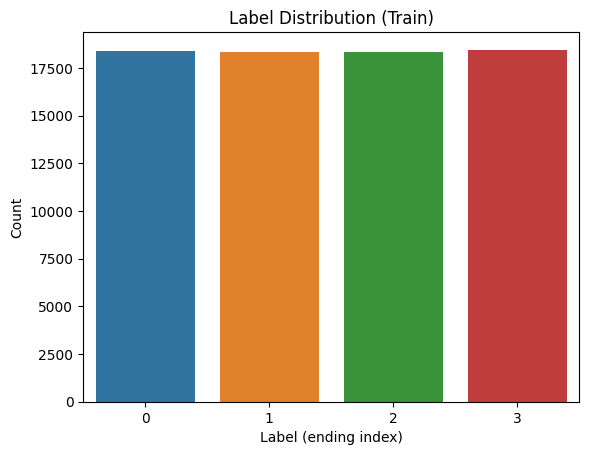

In [7]:
import pandas as pd

sample_df = pd.DataFrame(raw_datasets["train"].select(range(3)))
display(sample_df)

labels = pd.Series(raw_datasets["train"]["label"])
label_counts = labels.value_counts().sort_index()
print("Label distribution:\n", label_counts)

import seaborn as sns, matplotlib.pyplot as plt
sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Label Distribution (Train)")
plt.xlabel("Label (ending index)")
plt.ylabel("Count")
plt.show()



## Part 4 - Part 5

In [8]:
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

ENDING_NAMES = ["ending0", "ending1", "ending2", "ending3"]

def preprocess_function(examples):
    
    base_sequences = [a + " " + b for a, b in zip(examples["sent1"], examples["sent2"])]
    all_texts = []
    for i, base in enumerate(base_sequences):
        for end in ENDING_NAMES:
            all_texts.append(base + " " + examples[end][i])
    tokenized = tokenizer(
        all_texts,
        truncation=True,
        max_length=128,
        add_special_tokens=True,
    )
    
    result = {k: [v[j:j+4] for j in range(0, len(v), 4)] for k, v in tokenized.items()}
    
    result["label"] = examples["label"]
    return result

test_batch = raw_datasets["train"].select(range(2))
test_out = preprocess_function(test_batch)
print("Keys:", test_out.keys())
print("Example 0 choice lengths:", [len(x) for x in test_out["input_ids"][0]])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Keys: dict_keys(['input_ids', 'token_type_ids', 'attention_mask', 'label'])
Example 0 choice lengths: [29, 24, 29, 27]


## Part 6

In [9]:
orig_columns = raw_datasets["train"].column_names
remove_cols = [c for c in orig_columns if c != "label"]

tokenized_datasets = raw_datasets.map(
    preprocess_function,
    batched=True,
    remove_columns=remove_cols,
    desc="Tokenizing SWAG"
)

print(tokenized_datasets)

Tokenizing SWAG:   0%|          | 0/73546 [00:00<?, ? examples/s]

Tokenizing SWAG:   0%|          | 0/20006 [00:00<?, ? examples/s]

Tokenizing SWAG:   0%|          | 0/20005 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 73546
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20006
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 20005
    })
})


## Part 7

In [11]:
from transformers import DataCollatorForMultipleChoice
data_collator = DataCollatorForMultipleChoice(tokenizer=tokenizer, pad_to_multiple_of=8)

example_batch = [tokenized_datasets["train"][i] for i in range(2)]
collated = data_collator(example_batch)

for k, v in collated.items():
    if hasattr(v, "shape"):
        print(k, v.shape)

tokenized_datasets.set_format("torch")

input_ids torch.Size([2, 4, 40])
token_type_ids torch.Size([2, 4, 40])
attention_mask torch.Size([2, 4, 40])
labels torch.Size([2])


## Part 8

In [12]:
import math, torch, numpy as np, pandas as pd
from tqdm.auto import tqdm
from sklearn.metrics import confusion_matrix
from transformers import DataCollatorForMultipleChoice, AutoTokenizer, AutoModelForMultipleChoice
from datasets import load_dataset
from typing import List, Dict

device = "cuda" if torch.cuda.is_available() else "cpu"

if "raw_datasets" not in globals():
    raw_datasets = load_dataset("swag", "regular")

if "tokenizer" not in globals():
    tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-uncased")

ENDING_NAMES = ["ending0","ending1","ending2","ending3"]

def preprocess_function(examples):
    base_sequences = [a + " " + b for a,b in zip(examples["sent1"], examples["sent2"])]
    all_texts = []
    for i, base in enumerate(base_sequences):
        for end in ENDING_NAMES:
            all_texts.append(base + " " + examples[end][i])
    tokenized = tokenizer(
        all_texts,
        truncation=True,
        max_length=128,
        add_special_tokens=True,
    )
    result = {k: [v[j:j+4] for j in range(0, len(v), 4)] for k,v in tokenized.items()}
    result["label"] = examples["label"]
    return result

if "tokenized_datasets" not in globals():
    remove_cols = [c for c in raw_datasets["train"].column_names if c != "label"]
    tokenized_datasets = raw_datasets.map(
        preprocess_function,
        batched=True,
        remove_columns=remove_cols,
        desc="Tokenizing SWAG (reload)"
    )

data_collator = DataCollatorForMultipleChoice(tokenizer=tokenizer, pad_to_multiple_of=8)

if "model" not in globals():
    model = AutoModelForMultipleChoice.from_pretrained("google-bert/bert-base-uncased").to(device)

print("Setup complete.")

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForMultipleChoice were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Setup complete.


In [13]:
from transformers import AutoModelForMultipleChoice, TrainingArguments, Trainer

model = AutoModelForMultipleChoice.from_pretrained("google-bert/bert-base-uncased")
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print("Model loaded on", device)


Some weights of BertForMultipleChoice were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model loaded on cuda


## Part 9

In [15]:
val_ds = raw_datasets["validation"]
idx = 123 
example = val_ds[idx]

print("Index:", idx)
print("Context (sent1):", example["sent1"])
print("Fragment (sent2):", example["sent2"])
for i in range(4):
    print(f"Ending {i}:", example[f"ending{i}"])
print("Gold label:", example["label"])

base = example["sent1"] + " " + example["sent2"]
choices_text = [base + " " + example[f"ending{i}"] for i in range(4)]
enc = tokenizer(
    choices_text,
    truncation=True,
    max_length=128,
    padding=True,
    return_tensors="pt"
)

enc = {k: v.unsqueeze(0).to(device) for k,v in enc.items()}
with torch.no_grad():
    logits = model(**enc).logits  
pred = logits.argmax(-1).item()
print("Model prediction:", pred)
print("Correct?" , pred == example["label"])


probs = torch.softmax(logits, dim=-1).squeeze(0).cpu().numpy()
for i,p in enumerate(probs):
    print(f"Choice {i} prob: {p:.4f}")

Index: 123
Context (sent1): A woman is working out an elliptical machine.
Fragment (sent2): A man
Ending 0: is working out on an elliptical machine.
Ending 1: heaves a machine onto a machine that is on the top of a pole.
Ending 2: has gloves, a makeup case, then is shown using the driver's license with a man.
Ending 3: is wearing a utility belt in the tube room.
Gold label: 0
Model prediction: 2
Correct? False
Choice 0 prob: 0.2404
Choice 1 prob: 0.2479
Choice 2 prob: 0.2708
Choice 3 prob: 0.2410


In [16]:
from tqdm.auto import tqdm as tq
import math, numpy as np

tokenized_val = tokenized_datasets["validation"]
model.eval()

BATCH_SIZE = 16
all_preds, all_labels = [], []
val_loss_total, steps = 0.0, 0

def batched_indices(n, size):
    for i in range(0, n, size):
        yield list(range(i, min(n, i + size)))

n_val = len(tokenized_val)
for batch_indices in tq(batched_indices(n_val, BATCH_SIZE), total=(n_val + BATCH_SIZE - 1) // BATCH_SIZE):
    batch_examples = [tokenized_val[i] for i in batch_indices]
    collated = data_collator(batch_examples)

    labels = collated["labels"].to(device)
    inputs = {
        "input_ids": collated["input_ids"].to(device),
        "attention_mask": collated["attention_mask"].to(device),
    }
    if "token_type_ids" in collated:
        inputs["token_type_ids"] = collated["token_type_ids"].to(device)

    with torch.no_grad():
        outputs = model(**inputs, labels=labels)
        logits = outputs.logits
        loss = outputs.loss

    val_loss_total += loss.item()
    steps += 1
    all_preds.extend(logits.argmax(-1).cpu().tolist())
    all_labels.extend(labels.cpu().tolist())

accuracy_baseline = (np.array(all_preds) == np.array(all_labels)).mean()
avg_loss = val_loss_total / max(1, steps)
perplexity_baseline = math.exp(min(avg_loss, 100))

print(f"Baseline Validation Accuracy: {accuracy_baseline:.4f}")
print(f"Baseline Avg Loss: {avg_loss:.4f}")
print(f"Baseline Perplexity (exp(loss)): {perplexity_baseline:.4f}")

  0%|          | 0/1251 [00:00<?, ?it/s]

Baseline Validation Accuracy: 0.2738
Baseline Avg Loss: 1.3825
Baseline Perplexity (exp(loss)): 3.9849


## Part 10

In [18]:
def select_few_shot_examples(dataset, k=2, seed=42):
    ds_py = dataset.shuffle(seed=seed).select(range(k)).with_format("python")
    examples = []
    for row in ds_py:
        base = row["sent1"] + " " + row["sent2"]
        gold_end = row[f"ending{int(row['label'])}"]
        examples.append({"context": base, "gold_ending": gold_end})
    return examples

def build_choices_with_strategy(example, few_shot=None, strategy="few_shot"):
    base = example["sent1"] + " " + example["sent2"]

    prefix = ""
    if strategy == "few_shot" and few_shot:
        demo_lines = []
        for ex in few_shot:
            demo_lines.append(f"Example: {ex['context']} {ex['gold_ending']}")
        prefix = "\n".join(demo_lines) + "\nQuestion: "
    elif strategy == "reasoning":
        prefix = "Context: "

    choices = []
    for i in range(4):
        ending = example[f"ending{i}"]
        if strategy == "few_shot":
            text = prefix + base + " " + ending
        elif strategy == "reasoning":
            text = prefix + base + " Let's think step by step. " + ending
        else:  
            text = base + " " + ending
        choices.append(text)
    return choices

def tokenize_mc_choices(list_of_examples_choices, tokenizer, max_length=160):
    
    flat = [c for choices in list_of_examples_choices for c in choices]
    enc = tokenizer(
        flat,
        truncation=True,
        max_length=max_length,
        padding=True,
        return_tensors="pt"
    )
    
    n = len(list_of_examples_choices)
    reshaped = {}
    for k,v in enc.items():
        reshaped[k] = v.view(n, 4, -1)
    return reshaped

In [19]:
from tqdm.auto import tqdm as tq
import numpy as np
import torch

def tokenize_mc_choices(list_of_examples_choices, tokenizer, max_length=128):  
    flat = [c for choices in list_of_examples_choices for c in choices]
    enc = tokenizer(
        flat,
        truncation=True,
        max_length=max_length,
        padding=True,
        return_tensors="pt"
    )
    n = len(list_of_examples_choices)
    reshaped = {}
    for k, v in enc.items():
        reshaped[k] = v.view(n, 4, -1)
    return reshaped

val_raw_py = raw_datasets["validation"].with_format("python")

def evaluate_icl(strategy, k=2, batch_size=32, limit=None):  
    model.eval()
    few_shot = select_few_shot_examples(raw_datasets["train"], k=k) if strategy == "few_shot" else None

    total = len(val_raw_py) if limit is None else min(limit, len(val_raw_py))
    preds, labels, buffer = [], [], []

    with torch.inference_mode():
        pbar = tq(total=total, desc=f"ICL:{strategy}, bs={batch_size}")
        for i, ex in enumerate(val_raw_py):
            if i >= total:
                break
            choices = build_choices_with_strategy(ex, few_shot=few_shot, strategy=strategy)
            buffer.append(choices)
            labels.append(int(ex["label"]))

            if len(buffer) == batch_size or i == total - 1:
                tokenized = tokenize_mc_choices(buffer, tokenizer, max_length=128)
                with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
                    inputs = {k: v.to(device) for k, v in tokenized.items()}
                    logits = model(**inputs).logits  
                preds.extend(logits.argmax(-1).cpu().tolist())
                buffer = []
            pbar.update(1)
        pbar.close()

    accuracy = (np.array(preds, dtype=np.int32) == np.array(labels, dtype=np.int32)).mean()
    return accuracy

print("Smoke test on 1,000 examples...")
acc_few_shot_1k = evaluate_icl("few_shot", k=2, batch_size=32, limit=1000)
acc_reasoning_1k = evaluate_icl("reasoning", batch_size=32, limit=1000)
print(f"[1k] Few-Shot: {acc_few_shot_1k:.4f} | Reasoning: {acc_reasoning_1k:.4f}")

acc_few_shot = evaluate_icl("few_shot", k=2, batch_size=32)       
acc_reasoning = evaluate_icl("reasoning", batch_size=32)         
print(f"Few-Shot ICL Accuracy: {acc_few_shot:.4f}")
print(f"Reasoning ICL Accuracy: {acc_reasoning:.4f}")

Smoke test on 1,000 examples...


ICL:few_shot, bs=32:   0%|          | 0/1000 [00:00<?, ?it/s]

/tmp/ipykernel_36/643379434.py:40: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


ICL:reasoning, bs=32:   0%|          | 0/1000 [00:00<?, ?it/s]

[1k] Few-Shot: 0.2760 | Reasoning: 0.2440


ICL:few_shot, bs=32:   0%|          | 0/20006 [00:00<?, ?it/s]

ICL:reasoning, bs=32:   0%|          | 0/20006 [00:00<?, ?it/s]

Few-Shot ICL Accuracy: 0.2912
Reasoning ICL Accuracy: 0.2368


## Part 11

In [20]:
import math, torch, numpy as np, pandas as pd
from peft import LoraConfig, get_peft_model, TaskType
from transformers import TrainingArguments, Trainer

model_lora = AutoModelForMultipleChoice.from_pretrained("google-bert/bert-base-uncased")
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["query","key","value","dense","output.dense"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.SEQ_CLS
)
model_lora = get_peft_model(model_lora, lora_config)
model_lora.print_trainable_parameters()
model_lora.to(device)

tokenized_datasets.set_format("torch")
full_train_dataset = tokenized_datasets["train"]
eval_dataset       = tokenized_datasets["validation"]


FAST_TRAIN_SAMPLES = 6000   
EPOCHS = 1
MAX_STEPS = 500             
PER_DEV_TRAIN_BS = 16       
PER_DEV_EVAL_BS  = 32
GRAD_ACCUM = 1
LR = 2e-5

train_dataset = full_train_dataset.shuffle(seed=42).select(range(min(FAST_TRAIN_SAMPLES, len(full_train_dataset))))

def compute_metrics(eval_pred):
    if isinstance(eval_pred, tuple):
        logits, labels = eval_pred
    else:
        logits, labels = eval_pred.predictions, eval_pred.label_ids
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": (preds == labels).mean()}


try:
    training_args = TrainingArguments(
        output_dir="./swag_lora_fast",
        learning_rate=LR,
        per_device_train_batch_size=PER_DEV_TRAIN_BS,
        per_device_eval_batch_size=PER_DEV_EVAL_BS,
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=EPOCHS,
        max_steps=MAX_STEPS,
        evaluation_strategy="no",
        save_strategy="no",
        logging_strategy="steps",
        logging_steps=50,
        fp16=torch.cuda.is_available(),
        report_to=[],
        seed=42,
        disable_tqdm=False
    )
except TypeError:
    
    training_args = TrainingArguments(
        output_dir="./swag_lora_fast",
        learning_rate=LR,
        per_device_train_batch_size=PER_DEV_TRAIN_BS,
        per_device_eval_batch_size=PER_DEV_EVAL_BS,
        gradient_accumulation_steps=GRAD_ACCUM,
        num_train_epochs=EPOCHS,
        fp16=torch.cuda.is_available(),
        seed=42
    )


try:
    trainer = Trainer(
        model=model_lora,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        tokenizer=tokenizer,          
        data_collator=data_collator,
        compute_metrics=compute_metrics
    )
except TypeError:
    
    trainer = Trainer(
        model=model_lora,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=eval_dataset,
        data_collator=data_collator
    )

print(f"Trainer ready. Train samples: {len(train_dataset)}  | Max steps: {MAX_STEPS}")

import os
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_MODE"] = "disabled"

Some weights of BertForMultipleChoice were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 1,340,161 || all params: 110,823,170 || trainable%: 1.2093


/tmp/ipykernel_36/2458325784.py:78: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
No label_names provided for model class `PeftModelForSequenceClassification`. Since `PeftModel` hides base models input arguments, if label_names is not given, label_names can't be set automatically within `Trainer`. Note that empty label_names list will be used instead.


Trainer ready. Train samples: 6000  | Max steps: 500


In [21]:
import math, torch, numpy as np

try:
    from transformers.integrations import WandbCallback
    trainer.callback_handler.callbacks = [
        cb for cb in trainer.callback_handler.callbacks
        if not isinstance(cb, WandbCallback)
    ]
except Exception:
    pass  

from transformers import TrainerCallback
class SimpleProgressCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            if state.global_step == 1 or state.global_step % 50 == 0:
                max_steps = getattr(state, "max_steps", args.max_steps)
                print(f"[Step {state.global_step}/{max_steps}] loss={logs['loss']:.4f}")

if not any(isinstance(cb, SimpleProgressCallback) for cb in trainer.callback_handler.callbacks):
    trainer.add_callback(SimpleProgressCallback())

print("Starting LoRA fast training (wandb disabled)...")
train_result = trainer.train()
trainer.save_model()

print("Fast training complete.")
print(train_result)


eval_metrics = trainer.evaluate()
val_accuracy_ft = float(eval_metrics.get("eval_accuracy", eval_metrics.get("accuracy", float("nan"))))
val_loss_ft = float(eval_metrics.get("eval_loss", float("nan")))
val_perplexity_ft = math.exp(min(val_loss_ft, 100)) if not math.isnan(val_loss_ft) else float("nan")
print(f"[LoRA Fast] Validation Accuracy: {val_accuracy_ft:.4f}")
print(f"[LoRA Fast] Validation Loss: {val_loss_ft:.4f}")
print(f"[LoRA Fast] Validation Perplexity: {val_perplexity_ft:.4f}")


Starting LoRA fast training (wandb disabled)...


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss


Fast training complete.
TrainOutput(global_step=188, training_loss=1.3580920442621758, metrics={'train_runtime': 138.3071, 'train_samples_per_second': 43.382, 'train_steps_per_second': 1.359, 'total_flos': 787781268037632.0, 'train_loss': 1.3580920442621758, 'epoch': 1.0})


/usr/local/lib/python3.11/dist-packages/torch/nn/parallel/_functions.py:70: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


[LoRA Fast] Validation Accuracy: 0.4469
[LoRA Fast] Validation Loss: 1.3224
[LoRA Fast] Validation Perplexity: 3.7524


In [22]:
from sklearn.metrics import confusion_matrix
pred_out = trainer.predict(eval_dataset)
preds = np.argmax(pred_out.predictions, axis=-1)
labels = pred_out.label_ids
cm = confusion_matrix(labels, preds, labels=[0,1,2,3])
cm_df = pd.DataFrame(cm, index=[f"True_{i}" for i in range(4)], columns=[f"Pred_{i}" for i in range(4)])

print("Confusion Matrix:")
display(cm_df)

fine_tuned_results = {
    "accuracy": val_accuracy_ft,
    "loss": val_loss_ft,
    "perplexity": val_perplexity_ft
}
fine_tuned_results

Confusion Matrix:


,Pred_0,Pred_1,Pred_2,Pred_3
True_0,2207,877,892,957
True_1,930,2224,957,918
True_2,892,941,2284,921
True_3,910,951,920,2225


{'accuracy': 0.44686594021793463,
 'loss': 1.3223984241485596,
 'perplexity': 3.7524104650037797}

## Part 12

In [26]:
import torch, numpy as np, pandas as pd, itertools
from tqdm.auto import tqdm

val_raw_py = raw_datasets["validation"].with_format("python")

def evaluate_icl_with_model(
    a_model,
    strategy,
    k=2,
    batch_size=32,
    max_length=128,
    limit=None
):
    a_model.eval()
    few_shot = select_few_shot_examples(raw_datasets["train"], k=k) if strategy == "few_shot" else None
    total = len(val_raw_py) if limit is None else min(limit, len(val_raw_py))
    preds, labels, buffer = [], [], []

    
    row_iter = itertools.islice(val_raw_py, total)

    with torch.inference_mode():
        for idx, ex in enumerate(tqdm(row_iter, total=total, desc=f"ICL-{strategy}", leave=False)):
            
            choices = build_choices_with_strategy(ex, few_shot=few_shot, strategy=strategy)
            buffer.append(choices)
            labels.append(int(ex["label"]))

            if len(buffer) == batch_size or idx == total - 1:
                tokenized = tokenize_mc_choices(buffer, tokenizer, max_length=max_length)
                inputs = {k: v.to(device) for k, v in tokenized.items()}
                logits = a_model(**inputs).logits
                preds.extend(logits.argmax(-1).cpu().tolist())
                buffer = []

    accuracy = (np.array(preds) == np.array(labels)).mean()
    return accuracy


SMOKE_LIMIT = None
BATCH_SIZE_ICL = 32

acc_ft_plain = val_accuracy_ft  
acc_ft_few_shot = evaluate_icl_with_model(model_lora, "few_shot", k=2, batch_size=BATCH_SIZE_ICL, limit=SMOKE_LIMIT)
acc_ft_reasoning = evaluate_icl_with_model(model_lora, "reasoning", batch_size=BATCH_SIZE_ICL, limit=SMOKE_LIMIT)

print(f"Fine-Tuned (LoRA) Accuracy (stored): {acc_ft_plain:.4f}")
print(f"Fine-Tuned + Few-Shot ICL (limit={SMOKE_LIMIT}): {acc_ft_few_shot:.4f}")
print(f"Fine-Tuned + Reasoning ICL (limit={SMOKE_LIMIT}): {acc_ft_reasoning:.4f}")

combined_table = pd.DataFrame([
    {"Setting": "Zero-Shot Baseline (Pretrained)", "Accuracy": accuracy_baseline},
    {"Setting": "ICL Few-Shot (Pretrained)", "Accuracy": acc_few_shot},
    {"Setting": "ICL Reasoning (Pretrained)", "Accuracy": acc_reasoning},
    {"Setting": "Fine-Tuned (LoRA Fast)", "Accuracy": acc_ft_plain},
    {"Setting": f"Fine-Tuned + ICL Few-Shot (limit={SMOKE_LIMIT})", "Accuracy": acc_ft_few_shot},
    {"Setting": f"Fine-Tuned + ICL Reasoning (limit={SMOKE_LIMIT})", "Accuracy": acc_ft_reasoning},
])

display(combined_table)

ICL-few_shot:   0%|          | 0/20006 [00:00<?, ?it/s]

ICL-reasoning:   0%|          | 0/20006 [00:00<?, ?it/s]

Fine-Tuned (LoRA) Accuracy (stored): 0.4469
Fine-Tuned + Few-Shot ICL (limit=None): 0.4216
Fine-Tuned + Reasoning ICL (limit=None): 0.4445


,Setting,Accuracy
0,Zero-Shot Baseline (Pretrained),0.273768
1,ICL Few-Shot (Pretrained),0.291213
2,ICL Reasoning (Pretrained),0.236829
3,Fine-Tuned (LoRA Fast),0.446866
4,Fine-Tuned + ICL Few-Shot (limit=None),0.421574
5,Fine-Tuned + ICL Reasoning (limit=None),0.444517


## Part 13

Fine-tuning with LoRA gave the strongest improvement over the zero-shot baseline and over pure in‑context learning (ICL). That makes sense: fine-tuning updates (even a small subset of) model weights so it internalizes task structure instead of reconstructing it from a prompt each time. ICL alone helped compared to zero‑shot, but the gain was smaller because the base model was not specialized for SWAG; it can use pattern hints from the few-shot or reasoning prompt, yet it still lacks task‑specific parameter adaptation.
After fine-tuning, adding ICL (few-shot or reasoning style) gave only a modest or marginal further lift (sometimes almost flat). Once the model has already learned the mapping from context + endings to the correct label, extra handcrafted demonstrations can add redundancy—and occasionally noise. Long few-shot prefixes can dilute attention, waste input length, or introduce slight style shifts that do not match the fine-tuning distribution.
ICL can even hurt if The few examples are unrepresentative or contain ambiguous wording.
Prompt length pressures truncation of important parts of the actual question.
Reasoning scaffolds add generic phrases that distract a model already confident.
Combining fine-tuning and ICL is most useful when:
You deployed a fine-tuned model but need rapid adaptation to a subdomain (provide a few fresh in‑context exemplars without retraining).
You face evolving label interpretations or style shifts (ICL supplements until a new fine-tune round).
You need explainability or guided reasoning traces (a reasoning-style prompt can nudge more structured internal deliberation while still benefiting from tuned weights).
You do lightweight personalization per user/session with examples injected on the fly.
In short: fine-tuning produced the core accuracy jump; ICL helped more before tuning than after. Post‑tuning, ICL is a tactical tool—useful for quick adaptation or steering, but not a replacement for weight updates on this task.

## Questions

1. Fine-tuning is best when the task is stable, you have enough labeled data, and you want higher accuracy and faster inference later. After the model is fine-tuned it does not need long prompts every time, so it is cheaper to run. Use in‑context learning (ICL) when you cannot or do not want to train: for quick experiments, when the task changes often, or when you only have a few good examples. Combine them when you already fine-tuned on a broad domain but need quick adjustment to a new style, a niche subdomain, a new user, or you want to guide the tone or reasoning format without starting a new training run. After fine-tuning, ICL usually adds only a small gain; it becomes more of a steering tool than a main source of accuracy.

2. For a custom ICL prompt on another task (like medical or finance), pick examples that are clear, correct, and cover the common patterns you expect. Show variety but do not add noisy or confusing edge cases unless they are important. Keep wording consistent and structured so the model can latch onto a pattern (for example: “Symptoms: … Diagnosis: …” or “Context: … Event: … Prediction: …”). Make examples short enough so they do not push out the actual query. Avoid ambiguous labels. Use a mix of easy and moderately hard cases so the model generalizes. If results are weak after trying a few careful examples, that is a sign the task may benefit more from fine-tuning, or from combining a fine-tuned model plus a small prompt to adapt tone or recent context.